# Niche category-hours over time, stacked by title

**Purpose:** for each genre×platform "niche" cell with 2+ tracked titles, show
whether the niche itself is growing/shrinking (absolute hours, stack height)
and whether competitive balance within it is shifting (100%-normalized, every
stack the same height). Companion to `notebooks/niche_membership.ipynb`
(audience-similarity, a ~1-week snapshot) and `notebooks/esports_share_of_twitch.ipynb`
(aggregate esports-vs-Twitch share) — this one is about individual titles'
relative standing *within* their own niche, over the long run.

**Precondition check, done before anything else was built** (per explicit
instruction): does `pubg`'s platform tag match `apex_legends`/`fortnite`
(`pc_console`), so all three land in the same `battle_royale/pc_console`
niche cell? Confirmed directly below against both `config/titles.yaml` and
the live `titles` table — already `pc_console`, no fix was needed.

In [1]:
# Imports and repo path setup — same pattern as esports_share_of_twitch.ipynb.
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import yaml

from etl.db import get_connection

TITLES_CONFIG = REPO_ROOT / "config" / "titles.yaml"
conn = get_connection()

In [2]:
# Precondition check: pubg's platform tag vs. apex_legends/fortnite.
config_titles = yaml.safe_load(open(TITLES_CONFIG))["titles"]
platform_by_id = {t["id"]: t["platform"] for t in config_titles}
db_platform = dict(conn.execute(
    "SELECT t.id, p.name FROM titles t JOIN platforms p ON t.platform_id = p.id "
    "WHERE t.id IN ('pubg','apex_legends','fortnite')"
).fetchall())

for tid in ["pubg", "apex_legends", "fortnite"]:
    print(f"{tid:15} config={platform_by_id[tid]!r:12} db={db_platform.get(tid)!r}")

assert platform_by_id["pubg"] == "pc_console" == platform_by_id["apex_legends"] == platform_by_id["fortnite"], \
    "precondition failed — pubg does not match apex/fortnite's platform tag"
print("\nCONFIRMED: pubg's platform tag is pc_console, matching apex_legends and fortnite. No fix was needed.")

pubg            config='pc_console' db='pc_console'
apex_legends    config='pc_console' db='pc_console'
fortnite        config='pc_console' db='pc_console'

CONFIRMED: pubg's platform tag is pc_console, matching apex_legends and fortnite. No fix was needed.


## Data sources — and one instruction mismatch, resolved explicitly

The task that produced this notebook named a table `category_totals_snapshots`
as an own-collected data source. **That table does not exist in this
project's schema.** The closest real equivalent — and what this notebook
actually uses — is `monthly_category_history` with `source='own_collector'`:
a new aggregation (`etl/compute_monthly_category_totals.py`, built alongside
this notebook) that computes this project's own monthly category-wide
hours_watched per title from `language_mix_snapshots` (which folds in
below-threshold viewers too, unlike `viewership_snapshots` alone — see that
script's docstring), time-weighted by actual gaps between polls rather than
an assumed constant, since this project's polling is confirmed sparse and
irregular (40 polls over about a week, gaps from ~5 minutes to ~7.6 hours).
That table sits alongside `collectors/kaggle_import.py`'s
`source='kaggle_import'` rows in the same `monthly_category_history` table,
letting a single query span both eras.

In [3]:
# Load both sources of monthly_category_history and confirm the gap boundary.
rows = conn.execute(
    "SELECT title_id, year_month, source, hours_watched FROM monthly_category_history"
).fetchall()
mch = pd.DataFrame(rows, columns=["title_id", "year_month", "source", "hours_watched"])
mch["month"] = pd.to_datetime(mch["year_month"] + "-01")

kaggle_max = mch[mch.source == "kaggle_import"]["month"].max()
own_min = mch[mch.source == "own_collector"]["month"].min()
own_max = mch[mch.source == "own_collector"]["month"].max()
print(f"kaggle_import coverage ends: {kaggle_max.strftime('%Y-%m')}")
print(f"own_collector coverage: {own_min.strftime('%Y-%m')} to {own_max.strftime('%Y-%m')}")
print(f"gap: {kaggle_max.strftime('%Y-%m')} -> {own_min.strftime('%Y-%m')} "
      f"(~{(own_min.year-kaggle_max.year)*12 + (own_min.month-kaggle_max.month)} months, zero direct observation)")
print()
print("Every chart below leaves this gap visibly empty — the two segments are drawn as separate "
      "stackplot calls, not connected or interpolated across the gap.")

kaggle_import coverage ends: 2024-09
own_collector coverage: 2026-08 to 2026-09
gap: 2024-09 -> 2026-08 (~23 months, zero direct observation)

Every chart below leaves this gap visibly empty — the two segments are drawn as separate stackplot calls, not connected or interpolated across the gap.


In [4]:
# Build genre×platform niche cells (2+ titles) directly from config/titles.yaml.
from collections import defaultdict

niche_members = defaultdict(list)
for t in config_titles:
    niche_members[(t["genre"], t["platform"])].append(t["id"])
niche_cells = {k: v for k, v in niche_members.items() if len(v) >= 2}

print(f"{len(niche_cells)} niche cell(s) with 2+ tracked titles:")
for (genre, platform), members in sorted(niche_cells.items()):
    print(f"  {genre}/{platform}: {members}")

# Confirm every niche title has data on both sides of the gap (checked directly, not assumed).
missing = []
for members in niche_cells.values():
    for tid in members:
        has_k = ((mch.title_id == tid) & (mch.source == "kaggle_import")).any()
        has_o = ((mch.title_id == tid) & (mch.source == "own_collector")).any()
        if not (has_k and has_o):
            missing.append((tid, has_k, has_o))
if missing:
    print("\n[warn] titles missing coverage on one side:", missing)
else:
    print("\nAll niche titles have data on both sides of the gap — confirmed, not assumed.")

7 niche cell(s) with 2+ tracked titles:
  battle_royale/mobile: ['pubg_mobile', 'free_fire']
  battle_royale/pc_console: ['apex_legends', 'fortnite', 'pubg']
  fighting/console: ['tekken', 'street_fighter', 'mortal_kombat']
  moba/mobile: ['mobile_legends_bb', 'wild_rift']
  moba/pc: ['league_of_legends', 'dota2']
  rts/pc: ['starcraft2', 'age_of_empires_ii']
  tac_fps/pc: ['counter_strike', 'rainbow_six_siege', 'valorant']

All niche titles have data on both sides of the gap — confirmed, not assumed.


## Reading each chart

Left panel: absolute hours_watched, stacked — the total stack height is the
niche's overall size at that point in time; whether it's rising or falling
tells you if the niche is growing or shrinking. Right panel: the same data
normalized to 100% each month — every stack is the same height, so what
moves is purely *which title* holds how much of the niche, independent of
whether the niche as a whole is growing or shrinking. A niche can shrink in
absolute terms while staying perfectly balanced (normalized panel flat), or
grow while one title steadily displaces another (normalized panel shows a
clear trend) — these are different findings and the two panels are shown
side by side specifically so they don't get conflated.

In [5]:
def plot_niche(genre, platform, members, annotation=None):
    sub = mch[mch.title_id.isin(members)]
    colors = dict(zip(sorted(members), plt.get_cmap("tab10").colors))

    fig, (ax_abs, ax_norm) = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle(f"{genre} / {platform}  ({', '.join(sorted(members))})", fontsize=12)

    totals = {}
    for source in ("kaggle_import", "own_collector"):
        seg = (sub[sub.source == source]
               .pivot_table(index="month", columns="title_id", values="hours_watched", aggfunc="sum")
               .reindex(columns=sorted(members))
               .sort_index()
               .fillna(0.0))
        # fillna(0) matters: a title with no row for a given month genuinely
        # had zero hours_watched that month (hadn't launched, or fell out of
        # top-200) — matplotlib's stackplot silently DROPS any column with a
        # NaN in it entirely, which was chopping years off the start of a
        # chart (a 3-title niche where one title launched years later showed
        # NOTHING until all three had data, discovered and fixed while
        # building this — confirmed by rendering before/after).
        if seg.empty:
            continue
        cols = [colors[t] for t in seg.columns]
        ax_abs.stackplot(seg.index, *[seg[t] for t in seg.columns], colors=cols)
        norm = seg.div(seg.sum(axis=1), axis=0) * 100
        ax_norm.stackplot(norm.index, *[norm[t] for t in norm.columns], colors=cols)
        totals[source] = seg

    handles = [mpatches.Patch(color=colors[t], label=t) for t in sorted(members)]
    ax_abs.legend(handles=handles, loc="upper left", fontsize=8)
    ax_abs.set_title("Absolute hours_watched (stack height = niche size)")
    ax_abs.set_ylabel("hours_watched")
    ax_norm.set_title("100%-normalized (competitive balance only)")
    ax_norm.set_ylim(0, 100)
    ax_norm.set_ylabel("% of niche hours_watched")

    if annotation:
        fig.text(0.5, -0.04, annotation, ha="center", va="top", fontsize=8.5, wrap=True,
                  color="#444444", style="italic")

    fig.tight_layout()
    plt.show()

    # Headline numbers, printed (not just visual) — first/last absolute total, normalized-share delta.
    if "kaggle_import" in totals and "own_collector" in totals:
        k, o = totals["kaggle_import"], totals["own_collector"]
        first_total, last_total = k.sum(axis=1).iloc[0], o.sum(axis=1).iloc[-1]
        pct_change = 100 * (last_total - first_total) / first_total
        print(f"  niche total hours: {first_total:,.0f} ({k.index[0].strftime('%Y-%m')}) -> "
              f"{last_total:,.0f} ({o.index[-1].strftime('%Y-%m')})  ({pct_change:+.1f}%)")
        first_norm = (k.iloc[0] / k.iloc[0].sum() * 100).round(1)
        last_norm = (o.iloc[-1] / o.iloc[-1].sum() * 100).round(1)
        print(f"  normalized share, first month: {first_norm.to_dict()}")
        print(f"  normalized share, last month:  {last_norm.to_dict()}")

### battle_royale / mobile: free_fire, pubg_mobile

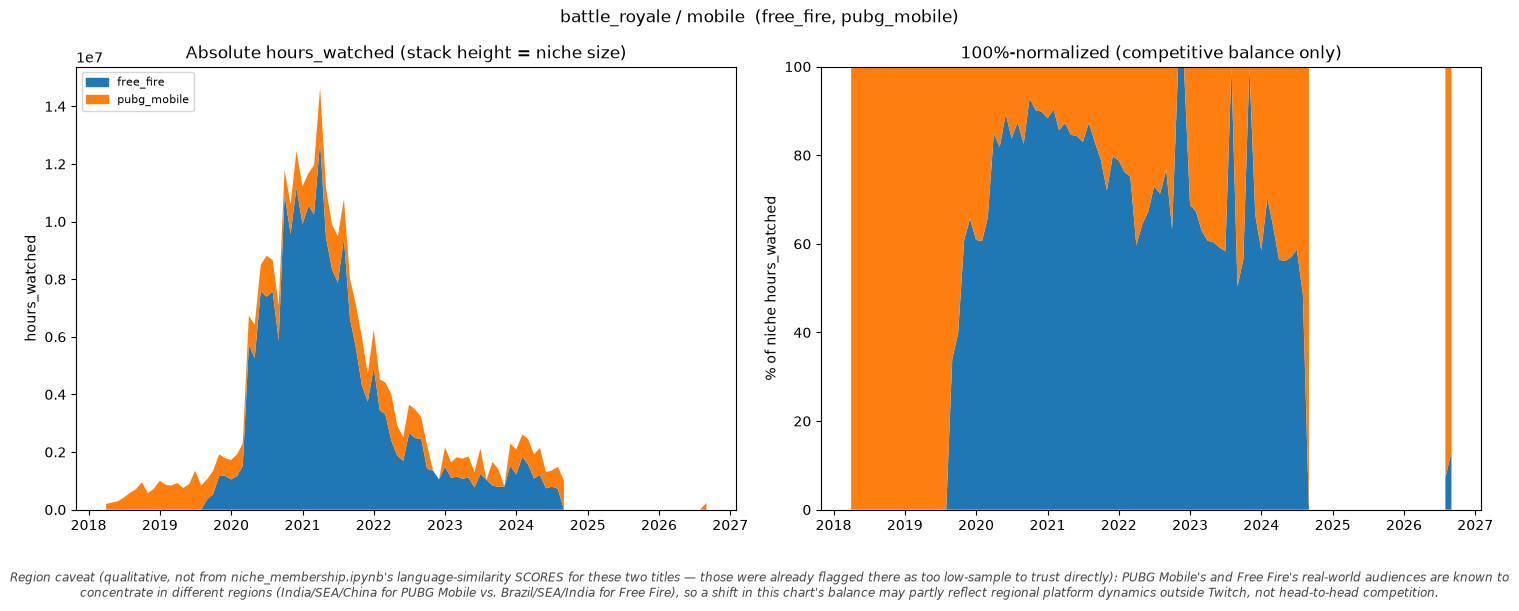

  niche total hours: 199,977 (2018-04) -> 230,421 (2026-09)  (+15.2%)
  normalized share, first month: {'free_fire': 0.0, 'pubg_mobile': 100.0}
  normalized share, last month:  {'free_fire': 13.0, 'pubg_mobile': 87.0}


In [6]:
plot_niche('battle_royale', 'mobile', ['pubg_mobile', 'free_fire'], annotation="Region caveat (qualitative, not from niche_membership.ipynb's language-similarity SCORES for these two titles \u2014 those were already flagged there as too low-sample to trust directly): PUBG Mobile's and Free Fire's real-world audiences are known to concentrate in different regions (India/SEA/China for PUBG Mobile vs. Brazil/SEA/India for Free Fire), so a shift in this chart's balance may partly reflect regional platform dynamics outside Twitch, not head-to-head competition.")

### battle_royale / pc_console: apex_legends, fortnite, pubg

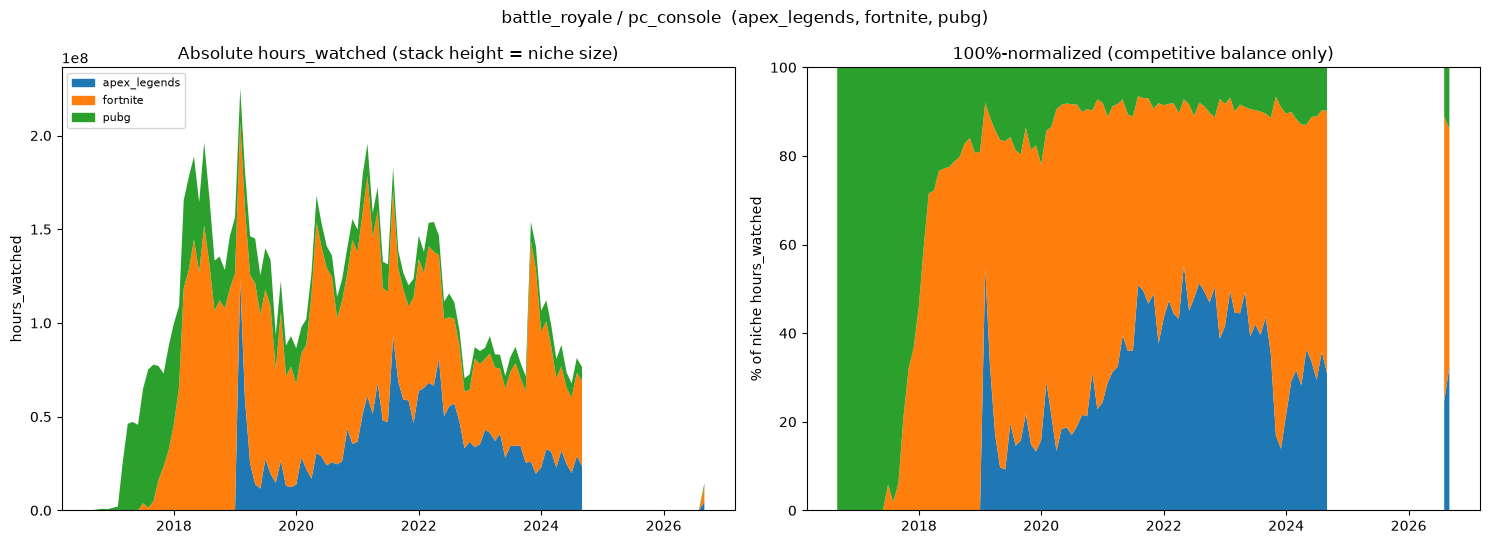

  niche total hours: 163,045 (2016-09) -> 14,464,207 (2026-09)  (+8771.3%)
  normalized share, first month: {'apex_legends': 0.0, 'fortnite': 0.0, 'pubg': 100.0}
  normalized share, last month:  {'apex_legends': 32.4, 'fortnite': 53.7, 'pubg': 13.9}


In [7]:
plot_niche('battle_royale', 'pc_console', ['apex_legends', 'fortnite', 'pubg'], annotation=None)

### fighting / console: mortal_kombat, street_fighter, tekken

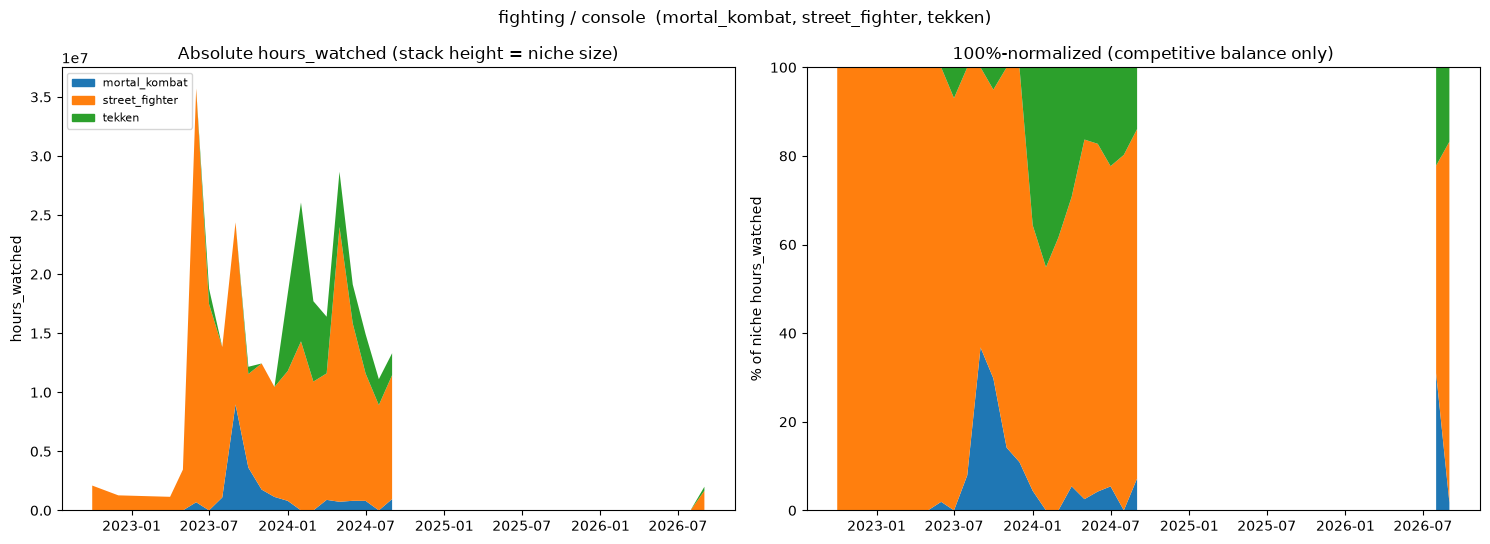

  niche total hours: 2,102,404 (2022-10) -> 2,001,779 (2026-09)  (-4.8%)
  normalized share, first month: {'mortal_kombat': 0.0, 'street_fighter': 100.0, 'tekken': 0.0}
  normalized share, last month:  {'mortal_kombat': 1.8, 'street_fighter': 81.4, 'tekken': 16.8}


In [8]:
plot_niche('fighting', 'console', ['tekken', 'street_fighter', 'mortal_kombat'], annotation=None)

### moba / mobile: mobile_legends_bb, wild_rift

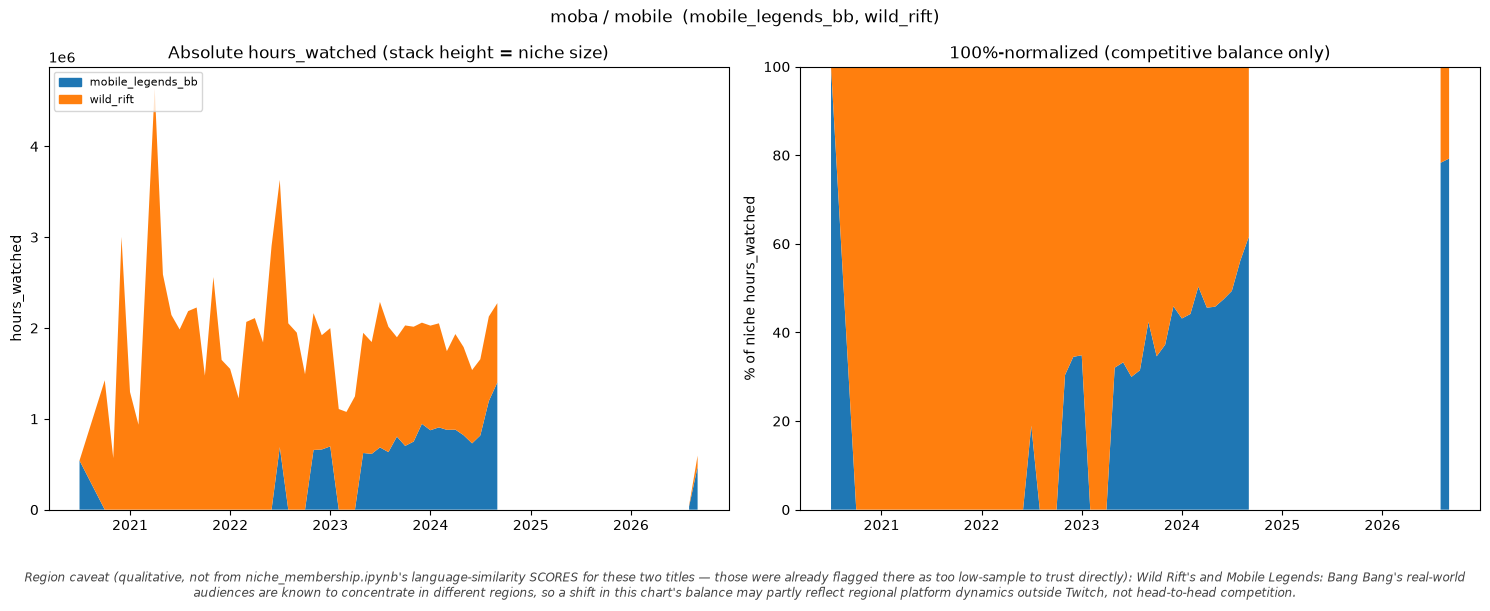

  niche total hours: 541,236 (2020-07) -> 595,262 (2026-09)  (+10.0%)
  normalized share, first month: {'mobile_legends_bb': 100.0, 'wild_rift': 0.0}
  normalized share, last month:  {'mobile_legends_bb': 79.2, 'wild_rift': 20.8}


In [9]:
plot_niche('moba', 'mobile', ['mobile_legends_bb', 'wild_rift'], annotation="Region caveat (qualitative, not from niche_membership.ipynb's language-similarity SCORES for these two titles \u2014 those were already flagged there as too low-sample to trust directly): Wild Rift's and Mobile Legends: Bang Bang's real-world audiences are known to concentrate in different regions, so a shift in this chart's balance may partly reflect regional platform dynamics outside Twitch, not head-to-head competition.")

### moba / pc: dota2, league_of_legends

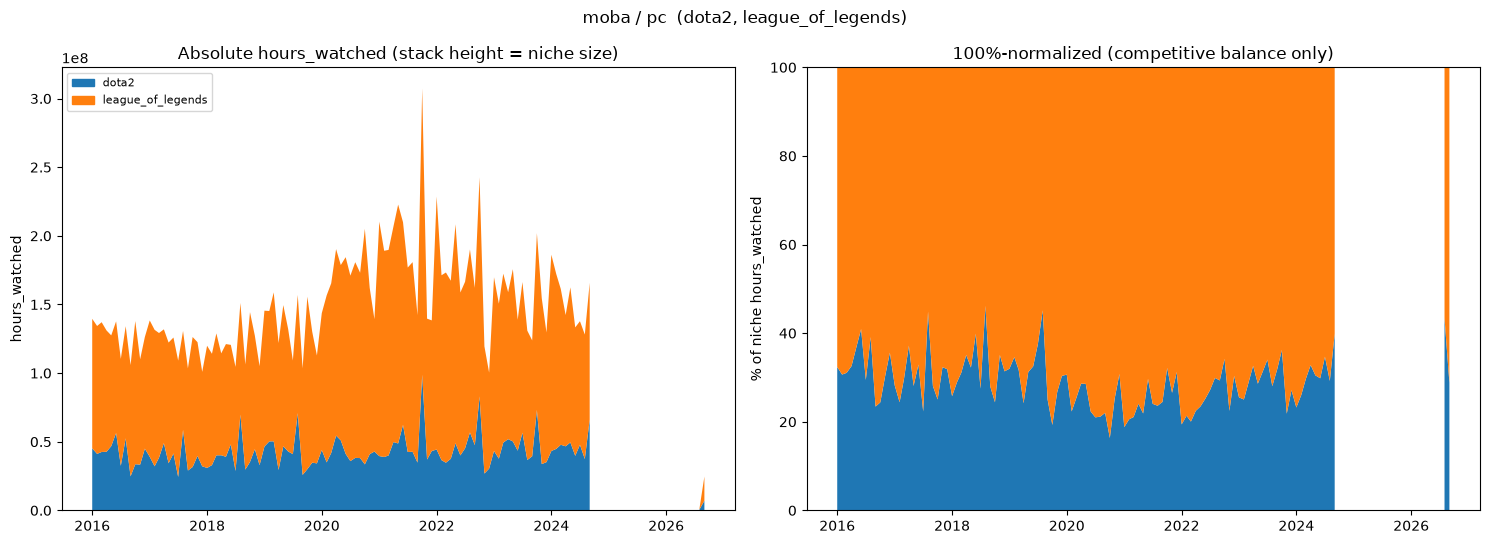

  niche total hours: 139,563,119 (2016-01) -> 24,664,339 (2026-09)  (-82.3%)
  normalized share, first month: {'dota2': 32.4, 'league_of_legends': 67.6}
  normalized share, last month:  {'dota2': 28.8, 'league_of_legends': 71.2}


In [10]:
plot_niche('moba', 'pc', ['league_of_legends', 'dota2'], annotation=None)

### rts / pc: age_of_empires_ii, starcraft2

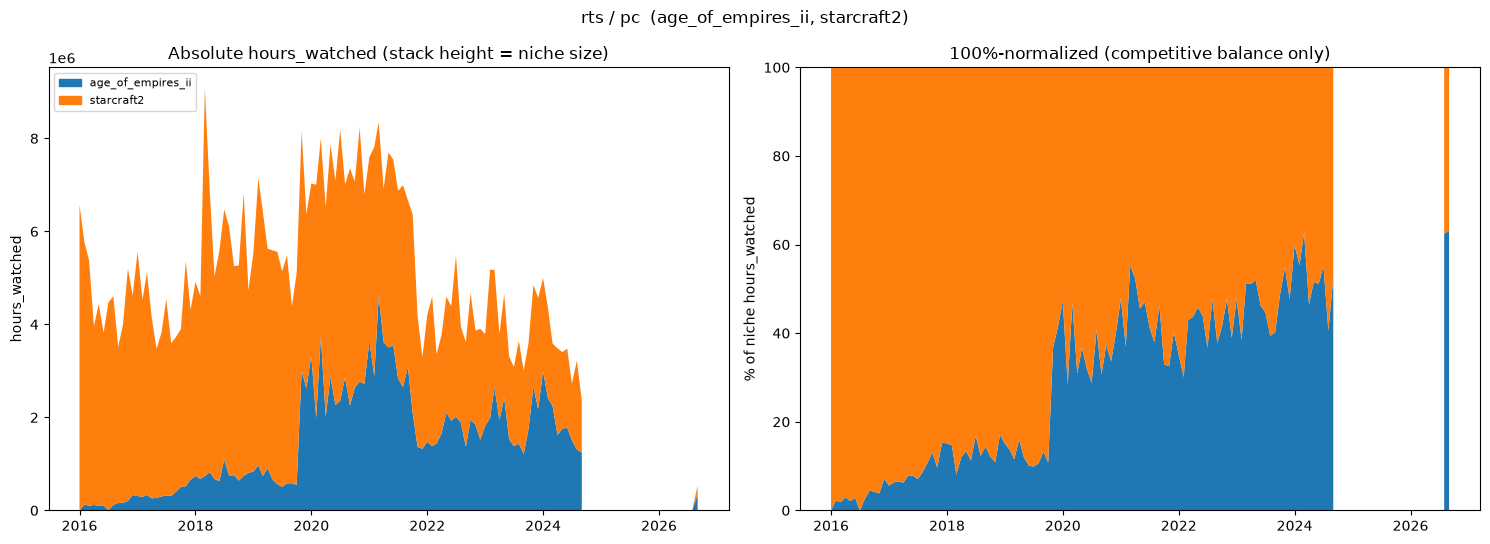

  niche total hours: 6,567,126 (2016-01) -> 529,520 (2026-09)  (-91.9%)
  normalized share, first month: {'age_of_empires_ii': 0.0, 'starcraft2': 100.0}
  normalized share, last month:  {'age_of_empires_ii': 63.1, 'starcraft2': 36.9}


In [11]:
plot_niche('rts', 'pc', ['starcraft2', 'age_of_empires_ii'], annotation=None)

### tac_fps / pc: counter_strike, rainbow_six_siege, valorant

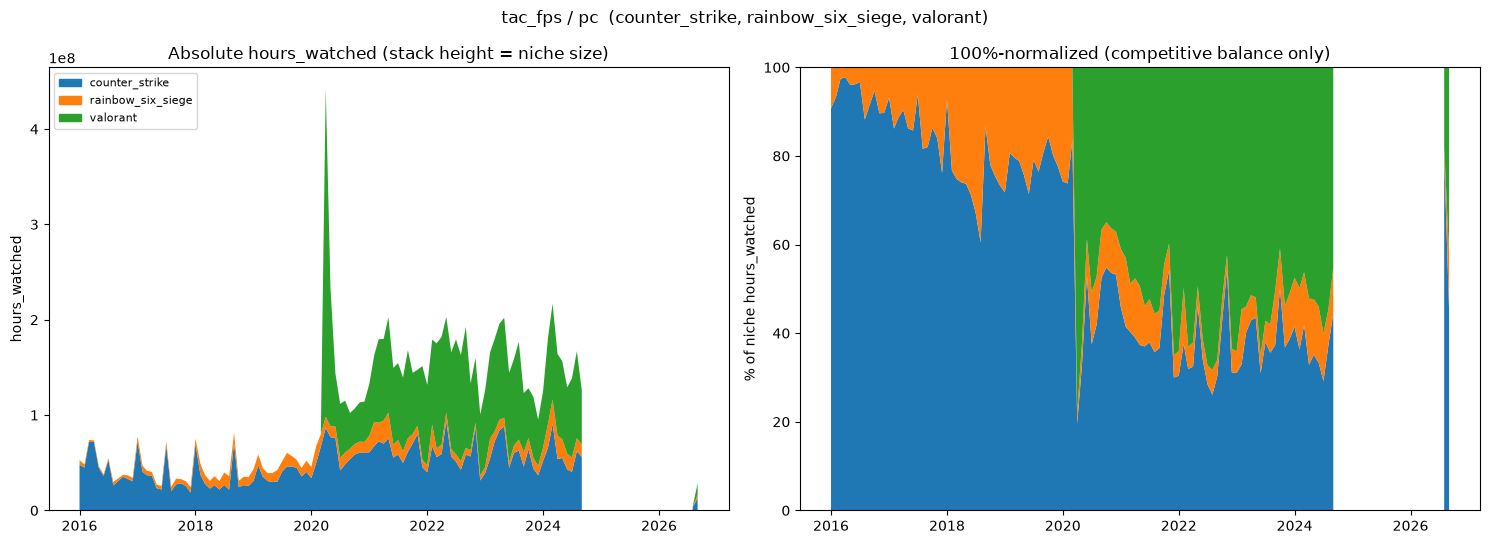

  niche total hours: 52,698,902 (2016-01) -> 28,275,090 (2026-09)  (-46.3%)
  normalized share, first month: {'counter_strike': 90.8, 'rainbow_six_siege': 9.2, 'valorant': 0.0}
  normalized share, last month:  {'counter_strike': 45.2, 'rainbow_six_siege': 12.6, 'valorant': 42.2}


In [12]:
plot_niche('tac_fps', 'pc', ['counter_strike', 'rainbow_six_siege', 'valorant'], annotation=None)

## Summary

Read the printed headline numbers above alongside each chart — the visual
gap between 2024-09 and 2026-08/09 is real and deliberate (23 months of zero
direct observation), not a rendering artifact. A niche whose absolute stack
clearly grew or shrank between the last Kaggle month and the current
own-collector months should be read with that gap explicitly in mind: two
points ~23 months apart say something about the endpoints, not about the
path between them.